# 15. LaMa CLIP and DINOv2 Feature-Space Similarity

This notebook computes CLIP and DINOv2 feature-space similarity metrics for the LaMa restoration baseline on the controlled 50-painting subset.

Feature similarity is computed between:

- clean reference and damaged input,
- clean reference and LaMa restored output.

Higher cosine similarity means higher feature-space similarity.

The evaluation reuses the same feature-similarity framework previously applied to OpenCV Telea, enabling later direct model comparison.

## Evaluation design

Feature-space similarity is computed over image-like spatial regions:

- `full_image`,
- `content_region`,
- `mask_bbox_crop`.

Sparse masked pixels are not evaluated directly because CLIP and DINOv2 expect spatial image inputs rather than unordered pixel sets.

For the controlled 50-painting subset, the expected output size is:

- 250 full-image rows,
- 250 content-region rows,
- 200 mask-bounding-box crop rows,

for a total of 700 feature-similarity metric rows.

Feature-similarity improvement is computed as:

`restored_similarity - damaged_similarity`

Positive improvement means that the restored output is closer to the clean reference in the selected feature space.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from restoration_eval.metrics_feature_similarity import (
    DEFAULT_CLIP_MODEL_NAME,
    DEFAULT_CROP_RESIZE,
    DEFAULT_DINOV2_MODEL_NAME,
    DEFAULT_MASK_BBOX_MARGIN,
    compute_feature_similarity_for_restorations,
    get_device,
    load_clip_model_and_processor,
    load_dinov2_model,
    rank_feature_similarity_cases,
    summarize_feature_similarity_metrics,
    validate_feature_similarity_metrics,
)

print("Project root:", PROJECT_ROOT)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]

metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

lama_metadata_path = processed_metadata_dir / "metadata_restored_lama.csv"
processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

feature_metrics_path = metrics_dir / "feature_similarity_lama_50.csv"
summary_by_mask_type_path = metrics_dir / "feature_similarity_summary_by_mask_type_lama_50.csv"
summary_by_category_path = metrics_dir / "feature_similarity_summary_by_category_lama_50.csv"
summary_by_region_path = metrics_dir / "feature_similarity_summary_by_region_lama_50.csv"
summary_by_region_mask_type_path = metrics_dir / "feature_similarity_summary_by_region_mask_type_lama_50.csv"
summary_by_category_region_path = metrics_dir / "feature_similarity_summary_by_category_region_lama_50.csv"

strongest_dinov2_cases_path = metrics_dir / "lama_strongest_dinov2_feature_cases_50.csv"
weakest_dinov2_cases_path = metrics_dir / "lama_weakest_dinov2_feature_cases_50.csv"
strongest_clip_cases_path = metrics_dir / "lama_strongest_clip_feature_cases_50.csv"
weakest_clip_cases_path = metrics_dir / "lama_weakest_clip_feature_cases_50.csv"

feature_diagnostic_figures_dir = figures_dir / "feature_similarity_diagnostics" / "lama"
feature_diagnostic_figures_dir.mkdir(parents=True, exist_ok=True)

model_name = "lama"
target_size = 768
clip_model_name = DEFAULT_CLIP_MODEL_NAME
dinov2_model_name = DEFAULT_DINOV2_MODEL_NAME
feature_resize = DEFAULT_CROP_RESIZE
mask_bbox_margin = DEFAULT_MASK_BBOX_MARGIN

print("LaMa metadata:", lama_metadata_path)
print("Processed clean metadata:", processed_clean_metadata_path)
print("Feature metrics output:", feature_metrics_path)
print("CLIP model:", clip_model_name)
print("DINOv2 model:", dinov2_model_name)
print("Feature resize:", feature_resize)
print("Mask bbox margin:", mask_bbox_margin)

LaMa metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_lama.csv
Processed clean metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Feature metrics output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_lama_50.csv
CLIP model: openai/clip-vit-base-patch32
DINOv2 model: dinov2_vits14
Feature resize: 224
Mask bbox margin: 32


In [3]:
required_input_paths = [
    lama_metadata_path,
    processed_clean_metadata_path,
]

for input_path in required_input_paths:
    if not input_path.exists():
        raise FileNotFoundError(f"Missing required input: {input_path}")

lama_restored_df = pd.read_csv(lama_metadata_path)
processed_clean_df = pd.read_csv(processed_clean_metadata_path)

print("Raw LaMa metadata shape:", lama_restored_df.shape)
print("Processed clean metadata shape:", processed_clean_df.shape)

metadata_lookup_columns = [
    "painting_id",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_lookup_columns = [
    column for column in metadata_lookup_columns
    if column not in processed_clean_df.columns
]

if missing_lookup_columns:
    raise ValueError(
        f"Processed clean metadata missing required lookup columns: {missing_lookup_columns}"
    )

metadata_lookup_df = (
    processed_clean_df[metadata_lookup_columns]
    .drop_duplicates(subset=["painting_id"])
    .copy()
)

if metadata_lookup_df["category"].isna().any():
    raise ValueError("Processed clean metadata contains missing category labels.")

lama_cases_df = lama_restored_df.copy()

columns_to_replace = [
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

lama_cases_df = lama_cases_df.drop(
    columns=[column for column in columns_to_replace if column in lama_cases_df.columns],
    errors="ignore",
)

lama_cases_df = lama_cases_df.merge(
    metadata_lookup_df,
    on="painting_id",
    how="left",
)

required_after_merge = [
    "category",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_after_merge = lama_cases_df[required_after_merge].isna().sum()

print("Missing values after metadata enrichment:")
display(missing_after_merge)

if missing_after_merge.sum() != 0:
    display(
        lama_cases_df[
            lama_cases_df[required_after_merge].isna().any(axis=1)
        ].head(20)
    )
    raise ValueError("LaMa metadata enrichment failed.")

print("Enriched LaMa metadata shape:", lama_cases_df.shape)

print("\nCategory counts:")
display(lama_cases_df["category"].value_counts().sort_index())

print("\nMask type counts:")
display(lama_cases_df["mask_type"].value_counts().sort_index())

display(
    lama_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "model_name",
            "status",
            "content_x_min",
            "content_y_min",
            "content_x_max",
            "content_y_max",
        ]
    ].head()
)

Raw LaMa metadata shape: (250, 32)
Processed clean metadata shape: (50, 43)
Missing values after metadata enrichment:


category         0
content_x_min    0
content_y_min    0
content_x_max    0
content_y_max    0
dtype: int64

Enriched LaMa metadata shape: (250, 38)

Category counts:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64

,case_id,painting_id,category,title,mask_type,model_name,status,content_x_min,content_y_min,content_x_max,content_y_max
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,lama,ok,52,0,715,768
1,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,lama,ok,52,0,715,768
2,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,lama,ok,52,0,715,768
3,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,lama,ok,52,0,715,768
4,p001_zero_control,p001,portrait_figure,Juan de Pareja,zero_control,lama,ok,52,0,715,768


In [4]:
required_case_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "mask_path",
    "damaged_path",
    "restored_path",
    "status",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_case_columns = [
    column for column in required_case_columns
    if column not in lama_cases_df.columns
]

if missing_case_columns:
    raise ValueError(f"LaMa cases metadata missing columns: {missing_case_columns}")

if len(lama_cases_df) != 250:
    raise ValueError(f"Expected 250 LaMa cases, found {len(lama_cases_df)}.")

if lama_cases_df["case_id"].duplicated().any():
    duplicate_case_ids = lama_cases_df.loc[
        lama_cases_df["case_id"].duplicated(),
        "case_id",
    ].tolist()
    raise ValueError(f"Duplicate case IDs found: {duplicate_case_ids[:10]}")

if (lama_cases_df["status"] != "ok").any():
    display(lama_cases_df[lama_cases_df["status"] != "ok"])
    raise ValueError("LaMa cases contain non-ok rows.")

if set(lama_cases_df["model_name"].unique()) != {model_name}:
    raise ValueError(
        f"Unexpected model names: {lama_cases_df['model_name'].unique()}"
    )

expected_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_mask_counts = lama_cases_df["mask_type"].value_counts().to_dict()

print("Expected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 50,
    "landscape_natural": 50,
    "architecture_structured": 50,
    "abstraction_surrealism": 50,
    "high_texture_brushwork": 50,
}

actual_category_counts = lama_cases_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

lama_cases_abs_df = lama_cases_df.copy()

for path_column in ["clean_path", "mask_path", "damaged_path", "restored_path"]:
    lama_cases_abs_df[path_column] = lama_cases_abs_df[path_column].apply(
        lambda value: str(PROJECT_ROOT / value) if not Path(value).is_absolute() else value
    )

missing_files = []

for path_column in ["clean_path", "mask_path", "damaged_path", "restored_path"]:
    missing_column_files = [
        path for path in lama_cases_abs_df[path_column]
        if not Path(path).exists()
    ]

    if missing_column_files:
        missing_files.extend(missing_column_files[:10])

if missing_files:
    raise FileNotFoundError(f"Missing image/mask files: {missing_files[:10]}")

print("\nLaMa feature-similarity metadata gates passed.")

Expected mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Expected category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}
Actual category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}

LaMa feature-similarity metadata gates passed.


In [5]:
device = get_device(prefer_cuda=True)

print("Selected device:", device)

clip_model, clip_processor = load_clip_model_and_processor(
    model_name=clip_model_name,
    device=device,
)

print("CLIP model loaded.")

dinov2_model = load_dinov2_model(
    model_name=dinov2_model_name,
    device=device,
)

print("DINOv2 model loaded.")

Selected device: cuda


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\huggingface_hub\file_download.py:147: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in E:\HFCache\transformers\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SY

CLIP model loaded.


C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 model loaded.


In [6]:
smoke_case_ids = []

# One non-zero damage case.
smoke_case_ids.append(
    lama_cases_abs_df[
        lama_cases_abs_df["mask_type"] != "zero_control"
    ]
    .sort_values("case_id")
    ["case_id"]
    .iloc[0]
)

# One zero-control sanity case.
smoke_case_ids.append(
    lama_cases_abs_df[
        lama_cases_abs_df["mask_type"] == "zero_control"
    ]
    .sort_values("case_id")
    ["case_id"]
    .iloc[0]
)

smoke_cases_df = (
    lama_cases_abs_df[
        lama_cases_abs_df["case_id"].isin(smoke_case_ids)
    ]
    .copy()
    .set_index("case_id")
    .loc[smoke_case_ids]
    .reset_index()
)

print("Smoke test cases:")
display(
    smoke_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "model_name",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ]
)

smoke_feature_df = compute_feature_similarity_for_restorations(
    restoration_metadata=smoke_cases_df,
    clip_model=clip_model,
    clip_processor=clip_processor,
    dinov2_model=dinov2_model,
    device=device,
    clip_model_name=clip_model_name,
    dinov2_model_name=dinov2_model_name,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    feature_resize=feature_resize,
    progress_every=1,
)

print("Smoke feature-similarity shape:", smoke_feature_df.shape)

display(smoke_feature_df)

Smoke test cases:


,case_id,painting_id,category,mask_type,model_name,clean_path,damaged_path,restored_path,mask_path
0,p001_loss_large,p001,portrait_figure,loss_large,lama,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_zero_control,p001,portrait_figure,zero_control,lama,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


Starting feature-similarity computation for 2 restoration cases...
Expected feature metric rows: 5
Device: cuda
CLIP model: openai/clip-vit-base-patch32
DINOv2 model: dinov2_vits14
Processed 1/2 restoration cases...
Processed 2/2 restoration cases...
Feature-similarity computation finished.
Smoke feature-similarity shape: (5, 28)


,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,clip_model_name,dinov2_model_name,feature_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,full_image,589824,0,...,0.061770,0.796219,0.984451,0.188231,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,content_region,509184,52,...,0.076606,0.790295,0.981506,0.191211,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,mask_bbox_crop,178929,197,...,0.166787,0.706465,0.960092,0.253627,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
3,p001_zero_control,p001,portrait_figure,Juan de Pareja,p001_zero_control,zero_control,lama,full_image,589824,0,...,0.000000,1.000000,1.000000,0.000000,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
4,p001_zero_control,p001,portrait_figure,Juan de Pareja,p001_zero_control,zero_control,lama,content_region,509184,52,...,0.000000,1.000000,1.000000,0.000000,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,


In [7]:
smoke_validation_df = validate_feature_similarity_metrics(
    smoke_feature_df,
    expected_rows=5,
)

print("Smoke feature-similarity validation:")
display(smoke_validation_df)

if not smoke_validation_df["passed"].all():
    display(smoke_feature_df)
    raise ValueError("Smoke feature-similarity validation failed.")

if (smoke_feature_df["status"] != "ok").any():
    display(smoke_feature_df[smoke_feature_df["status"] != "ok"])
    raise ValueError("Smoke feature-similarity contains non-ok rows.")

print("Smoke feature-similarity test passed.")

Smoke feature-similarity validation:


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 5, found 5."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 2, 'content_region': 2, 'mask_b..."


Smoke feature-similarity test passed.


In [8]:
feature_metrics_df = compute_feature_similarity_for_restorations(
    restoration_metadata=lama_cases_abs_df,
    clip_model=clip_model,
    clip_processor=clip_processor,
    dinov2_model=dinov2_model,
    device=device,
    clip_model_name=clip_model_name,
    dinov2_model_name=dinov2_model_name,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    feature_resize=feature_resize,
    progress_every=25,
)

print("LaMa feature-similarity metrics shape:", feature_metrics_df.shape)

display(feature_metrics_df.head())

print("\nEvaluation region counts:")
display(feature_metrics_df["evaluation_region"].value_counts())

print("\nMask type counts:")
display(feature_metrics_df["mask_type"].value_counts().sort_index())

print("\nCategory counts:")
display(feature_metrics_df["category"].value_counts().sort_index())

print("\nStatus counts:")
display(feature_metrics_df["status"].value_counts(dropna=False))

if (feature_metrics_df["status"] != "ok").any():
    display(feature_metrics_df[feature_metrics_df["status"] != "ok"])
    raise ValueError("Some LaMa feature-similarity rows failed.")

print("Full LaMa feature-similarity computation completed.")

Starting feature-similarity computation for 250 restoration cases...
Expected feature metric rows: 700
Device: cuda
CLIP model: openai/clip-vit-base-patch32
DINOv2 model: dinov2_vits14
Processed 1/250 restoration cases...
Processed 25/250 restoration cases...
Processed 50/250 restoration cases...
Processed 75/250 restoration cases...
Processed 100/250 restoration cases...
Processed 125/250 restoration cases...
Processed 150/250 restoration cases...
Processed 175/250 restoration cases...
Processed 200/250 restoration cases...
Processed 225/250 restoration cases...
Processed 250/250 restoration cases...
Feature-similarity computation finished.
LaMa feature-similarity metrics shape: (700, 28)


,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,clip_model_name,dinov2_model_name,feature_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,full_image,589824,0,...,0.061770,0.796219,0.984451,0.188231,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,content_region,509184,52,...,0.076606,0.790295,0.981506,0.191211,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,mask_bbox_crop,178929,197,...,0.166787,0.706465,0.960092,0.253627,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
3,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,lama,full_image,589824,0,...,0.084684,0.935493,0.999762,0.064270,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,lama,content_region,509184,52,...,0.078855,0.932966,0.999726,0.066760,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,



Evaluation region counts:


evaluation_region
full_image        250
content_region    250
mask_bbox_crop    200
Name: count, dtype: int64


Mask type counts:


...


Category counts:


category
abstraction_surrealism     140
architecture_structured    140
high_texture_brushwork     140
landscape_natural          140
portrait_figure            140
Name: count, dtype: int64


Status counts:


status
ok    700
Name: count, dtype: int64

Full LaMa feature-similarity computation completed.


In [9]:
feature_validation_df = validate_feature_similarity_metrics(
    feature_metrics_df,
    expected_rows=700,
)

print("LaMa feature-similarity validation:")
display(feature_validation_df)

if not feature_validation_df["passed"].all():
    raise ValueError("LaMa feature-similarity validation failed.")

if (feature_metrics_df["status"] != "ok").any():
    display(feature_metrics_df[feature_metrics_df["status"] != "ok"])
    raise ValueError("LaMa feature-similarity output contains non-ok rows.")

expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "mask_bbox_crop": 200,
}

actual_region_counts = feature_metrics_df["evaluation_region"].value_counts().to_dict()

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", actual_region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = actual_region_counts.get(region, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Region {region!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 140,
    "landscape_natural": 140,
    "architecture_structured": 140,
    "abstraction_surrealism": 140,
    "high_texture_brushwork": 140,
}

actual_category_counts = feature_metrics_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

print("LaMa feature-similarity validation passed.")

LaMa feature-similarity validation:


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 700, found 700."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 250, 'content_region': 250, 'ma..."


Expected region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}

Expected category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
Actual category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
LaMa feature-similarity validation passed.


In [10]:
feature_metrics_df.to_csv(feature_metrics_path, index=False)

print("Saved LaMa feature-similarity metrics:")
print(feature_metrics_path)

saved_feature_df = pd.read_csv(feature_metrics_path)

print("Saved shape:", saved_feature_df.shape)

if len(saved_feature_df) != 700:
    raise ValueError(
        f"Expected 700 saved feature-similarity rows, found {len(saved_feature_df)}."
    )

if (saved_feature_df["status"] != "ok").any():
    display(saved_feature_df[saved_feature_df["status"] != "ok"])
    raise ValueError("Saved LaMa feature-similarity metrics contain non-ok rows.")

print("Full LaMa feature-similarity metrics saved successfully.")

Saved LaMa feature-similarity metrics:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_lama_50.csv
Saved shape: (700, 28)
Full LaMa feature-similarity metrics saved successfully.


In [11]:
summary_by_mask_type_df = summarize_feature_similarity_metrics(
    feature_metrics_df,
    group_columns=["mask_type"],
)

summary_by_category_df = summarize_feature_similarity_metrics(
    feature_metrics_df,
    group_columns=["category"],
)

summary_by_region_df = summarize_feature_similarity_metrics(
    feature_metrics_df,
    group_columns=["evaluation_region"],
)

summary_by_region_mask_type_df = summarize_feature_similarity_metrics(
    feature_metrics_df,
    group_columns=["evaluation_region", "mask_type"],
)

summary_by_category_region_df = summarize_feature_similarity_metrics(
    feature_metrics_df,
    group_columns=["category", "evaluation_region"],
)

print("Summary by mask type:")
display(summary_by_mask_type_df)

print("\nSummary by category:")
display(summary_by_category_df)

print("\nSummary by evaluation region:")
display(summary_by_region_df)

print("\nSummary by evaluation region and mask type:")
display(summary_by_region_mask_type_df)

print("\nSummary by category and evaluation region:")
display(summary_by_category_region_df)

Summary by mask type:


,mask_type,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,loss_large,150,50,0.85520,0.97774,0.12254,0.11476,1.0,0.81548,0.93573,0.12026,0.08825,0.97333,406007.07333
1,loss_small,150,50,0.89876,0.99789,0.09913,0.09309,1.0,0.90796,0.99510,0.08714,0.04940,1.00000,489403.76000
2,mixed_damage,150,50,0.84140,0.99462,0.15322,0.16056,1.0,0.76293,0.98418,0.22125,0.16659,1.00000,538795.30667
3,scratch_thin,150,50,0.89722,0.99935,0.10212,0.10258,1.0,0.85271,0.99727,0.14456,0.11569,1.00000,538267.44667
4,zero_control,100,50,1.00000,1.00000,0.00000,0.00000,0.0,1.00000,1.00000,0.00000,0.00000,0.00000,522240.00000



Summary by category:


,category,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,abstraction_surrealism,140,50,0.92535,0.99441,0.06906,0.06335,0.85714,0.91287,0.98171,0.06884,0.05589,0.85714,524982.70000
1,architecture_structured,140,50,0.87098,0.99311,0.12212,0.12796,0.85714,0.89525,0.98193,0.08668,0.05330,0.85000,482446.84286
2,high_texture_brushwork,140,50,0.88560,0.99259,0.10699,0.10924,0.85714,0.83053,0.97813,0.14761,0.10455,0.83571,496638.98571
3,landscape_natural,140,50,0.88500,0.99469,0.10969,0.11678,0.85714,0.78932,0.98314,0.19381,0.15684,0.85714,480574.62143
4,portrait_figure,140,50,0.88942,0.99262,0.10320,0.10175,0.85714,0.86389,0.98111,0.11722,0.09043,0.85714,501749.97857



Summary by evaluation region:


,evaluation_region,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,content_region,250,250,0.89765,0.99515,0.09750,0.09645,0.8,0.88212,0.98587,0.10375,0.06655,0.796,454656.00
1,full_image,250,250,0.90947,0.99558,0.08612,0.08480,0.8,0.86507,0.98662,0.12155,0.07622,0.792,589824.00
2,mask_bbox_crop,200,200,0.86055,0.98878,0.12823,0.12448,1.0,0.82032,0.96860,0.14828,0.10744,0.995,434875.19



Summary by evaluation region and mask type:


,evaluation_region,mask_type,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,content_region,loss_large,50,50,0.86659,0.98468,0.11810,0.11466,1.0,0.84586,0.95458,0.10872,0.07500,0.98,454656.00
1,content_region,loss_small,50,50,0.89482,0.99797,0.10315,0.09653,1.0,0.91281,0.99505,0.08224,0.04509,1.00,454656.00
2,content_region,mixed_damage,50,50,0.83301,0.99381,0.16080,0.15959,1.0,0.78871,0.98273,0.19402,0.14037,1.00,454656.00
3,content_region,scratch_thin,50,50,0.89381,0.99927,0.10546,0.09937,1.0,0.86320,0.99697,0.13377,0.10772,1.00,454656.00
4,content_region,zero_control,50,50,1.00000,1.00000,0.00000,0.00000,0.0,1.00000,1.00000,0.00000,0.00000,0.00,454656.00
5,full_image,loss_large,50,50,0.89394,0.98527,0.09133,0.08276,1.0,0.83905,0.95561,0.11655,0.08234,0.96,589824.00
6,full_image,loss_small,50,50,0.90769,0.99822,0.09053,0.08920,1.0,0.89479,0.99512,0.10034,0.05401,1.00,589824.00
7,full_image,mixed_damage,50,50,0.84591,0.99496,0.14905,0.15481,1.0,0.74694,0.98474,0.23780,0.18278,1.00,589824.00
8,full_image,scratch_thin,50,50,0.89980,0.99947,0.09967,0.10386,1.0,0.84456,0.99763,0.15307,0.12052,1.00,589824.00
9,full_image,zero_control,50,50,1.00000,1.00000,0.00000,0.00000,0.0,1.00000,1.00000,0.00000,0.00000,0.00,589824.00



Summary by category and evaluation region:


,category,evaluation_region,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,abstraction_surrealism,content_region,50,50,0.93406,0.99611,0.06205,0.05804,0.8,0.92953,0.98697,0.05744,0.05059,0.800,506419.200
1,abstraction_surrealism,full_image,50,50,0.93469,0.99582,0.06113,0.05678,0.8,0.92479,0.98717,0.06238,0.04681,0.800,589824.000
2,abstraction_surrealism,mask_bbox_crop,40,40,0.90277,0.99053,0.08776,0.07268,1.0,0.87714,0.96830,0.09116,0.07600,1.000,467135.450
3,architecture_structured,content_region,50,50,0.87054,0.99488,0.12434,0.14132,0.8,0.91166,0.98568,0.07402,0.04912,0.800,437760.000
4,architecture_structured,full_image,50,50,0.89898,0.99522,0.09624,0.09935,0.8,0.90061,0.98676,0.08615,0.05085,0.780,589824.000
5,architecture_structured,mask_bbox_crop,40,40,0.83654,0.98825,0.15171,0.14883,1.0,0.86804,0.97118,0.10315,0.07930,1.000,404083.950
6,high_texture_brushwork,content_region,50,50,0.89607,0.99398,0.09790,0.10436,0.8,0.85989,0.98313,0.12323,0.09159,0.780,458803.200
7,high_texture_brushwork,full_image,50,50,0.90590,0.99508,0.08918,0.09120,0.8,0.83420,0.98416,0.14996,0.08925,0.780,589824.000
8,high_texture_brushwork,mask_bbox_crop,40,40,0.84712,0.98773,0.14061,0.13801,1.0,0.78922,0.96435,0.17513,0.13785,0.975,427452.450
9,landscape_natural,content_region,50,50,0.89073,0.99586,0.10513,0.12591,0.8,0.82414,0.98721,0.16308,0.11700,0.800,413030.400


In [12]:
summary_by_mask_type_df.to_csv(summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(summary_by_category_path, index=False)
summary_by_region_df.to_csv(summary_by_region_path, index=False)
summary_by_region_mask_type_df.to_csv(summary_by_region_mask_type_path, index=False)
summary_by_category_region_df.to_csv(summary_by_category_region_path, index=False)

saved_summary_paths = [
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    summary_by_category_region_path,
]

print("Saved feature-similarity summary files:")

for path in saved_summary_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing saved summary file: {path}")
    print(path)

print("All LaMa feature-similarity summary files saved.")

Saved feature-similarity summary files:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_mask_type_lama_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_category_lama_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_region_lama_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_region_mask_type_lama_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_category_region_lama_50.csv
All LaMa feature-similarity summary files saved.


In [13]:
strongest_dinov2_cases_df, weakest_dinov2_cases_df = rank_feature_similarity_cases(
    feature_metrics_df,
    evaluation_region="mask_bbox_crop",
    metric="dinov2_similarity_improvement",
    top_n=20,
)

print("Strongest LaMa DINOv2 feature-similarity improvement cases:")
display(
    strongest_dinov2_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "evaluation_region",
            "dinov2_damaged_similarity",
            "dinov2_restored_similarity",
            "dinov2_similarity_improvement",
        ]
    ]
)

print("\nWeakest LaMa DINOv2 feature-similarity improvement cases:")
display(
    weakest_dinov2_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "evaluation_region",
            "dinov2_damaged_similarity",
            "dinov2_restored_similarity",
            "dinov2_similarity_improvement",
        ]
    ]
)

if len(strongest_dinov2_cases_df) != 20:
    raise ValueError(
        f"Expected 20 strongest DINOv2 cases, found {len(strongest_dinov2_cases_df)}."
    )

if len(weakest_dinov2_cases_df) != 20:
    raise ValueError(
        f"Expected 20 weakest DINOv2 cases, found {len(weakest_dinov2_cases_df)}."
    )

print("LaMa DINOv2 feature-similarity ranking completed.")

Strongest LaMa DINOv2 feature-similarity improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p014_mixed_damage,p014,landscape_natural,Landscape on a River,mixed_damage,mask_bbox_crop,0.333144,0.990326,0.657182
1,p050_mixed_damage,p050,high_texture_brushwork,Landscape with a Sunlit Stream,mixed_damage,mask_bbox_crop,0.395456,0.973586,0.578130
2,p048_mixed_damage,p048,high_texture_brushwork,A Farm in Brittany,mixed_damage,mask_bbox_crop,0.409864,0.976129,0.566265
3,p010_mixed_damage,p010,portrait_figure,Joan of Arc,mixed_damage,mask_bbox_crop,0.462198,0.980454,0.518256
4,p011_mixed_damage,p011,landscape_natural,View of Haarlem and the Haarlemmer Meer,mixed_damage,mask_bbox_crop,0.511711,0.988327,0.476616
5,p011_loss_large,p011,landscape_natural,View of Haarlem and the Haarlemmer Meer,loss_large,mask_bbox_crop,0.488416,0.960426,0.472010
6,p015_mixed_damage,p015,landscape_natural,Landscape,mixed_damage,mask_bbox_crop,0.565538,0.987187,0.421648
7,p027_mixed_damage,p027,architecture_structured,Italian Landscape with the Ponte Lucano over t...,mixed_damage,mask_bbox_crop,0.574332,0.995275,0.420943
8,p044_mixed_damage,p044,high_texture_brushwork,Versailles,mixed_damage,mask_bbox_crop,0.576658,0.993416,0.416758
9,p020_mixed_damage,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,mixed_damage,mask_bbox_crop,0.585342,0.966918,0.381576



Weakest LaMa DINOv2 feature-similarity improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p046_loss_large,p046,high_texture_brushwork,Boating,loss_large,mask_bbox_crop,0.786227,0.685472,-0.100755
1,p036_scratch_thin,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",scratch_thin,mask_bbox_crop,0.973013,0.979536,0.006523
2,p036_mixed_damage,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",mixed_damage,mask_bbox_crop,0.948041,0.956850,0.008810
3,p028_loss_large,p028,architecture_structured,Trading posts of the Dutch East India Company ...,loss_large,mask_bbox_crop,0.881481,0.893047,0.011566
4,p004_loss_large,p004,portrait_figure,Madame Georges Charpentier and Her Children,loss_large,mask_bbox_crop,0.886081,0.898065,0.011984
5,p035_loss_small,p035,abstraction_surrealism,The Bewitched Mill,loss_small,mask_bbox_crop,0.979415,0.994295,0.014880
6,p023_loss_small,p023,architecture_structured,Church Interior,loss_small,mask_bbox_crop,0.982123,0.998843,0.016720
7,p019_loss_small,p019,landscape_natural,Evening: Landscape with an Aqueduct,loss_small,mask_bbox_crop,0.982943,0.999691,0.016747
8,p024_loss_small,p024,architecture_structured,Interior of the Church of St Bavo in Haarlem,loss_small,mask_bbox_crop,0.970639,0.987729,0.017091
9,p004_loss_small,p004,portrait_figure,Madame Georges Charpentier and Her Children,loss_small,mask_bbox_crop,0.979838,0.998575,0.018737


LaMa DINOv2 feature-similarity ranking completed.


In [14]:
strongest_clip_cases_df, weakest_clip_cases_df = rank_feature_similarity_cases(
    feature_metrics_df,
    evaluation_region="mask_bbox_crop",
    metric="clip_similarity_improvement",
    top_n=20,
)

print("Strongest LaMa CLIP feature-similarity improvement cases:")
display(
    strongest_clip_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "evaluation_region",
            "clip_damaged_similarity",
            "clip_restored_similarity",
            "clip_similarity_improvement",
        ]
    ]
)

print("\nWeakest LaMa CLIP feature-similarity improvement cases:")
display(
    weakest_clip_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "evaluation_region",
            "clip_damaged_similarity",
            "clip_restored_similarity",
            "clip_similarity_improvement",
        ]
    ]
)

if len(strongest_clip_cases_df) != 20:
    raise ValueError(
        f"Expected 20 strongest CLIP cases, found {len(strongest_clip_cases_df)}."
    )

if len(weakest_clip_cases_df) != 20:
    raise ValueError(
        f"Expected 20 weakest CLIP cases, found {len(weakest_clip_cases_df)}."
    )

print("LaMa CLIP feature-similarity ranking completed.")

Strongest LaMa CLIP feature-similarity improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement
0,p050_loss_large,p050,high_texture_brushwork,Landscape with a Sunlit Stream,loss_large,mask_bbox_crop,0.589563,0.933733,0.344170
1,p013_mixed_damage,p013,landscape_natural,Landscape with a Village in the Distance,mixed_damage,mask_bbox_crop,0.724590,0.999137,0.274547
2,p022_loss_large,p022,architecture_structured,"Interior of a Protestant, Gothic Church, with ...",loss_large,mask_bbox_crop,0.721413,0.969575,0.248162
3,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,mask_bbox_crop,0.724333,0.969885,0.245552
4,p049_loss_large,p049,high_texture_brushwork,Peonies,loss_large,mask_bbox_crop,0.716942,0.950417,0.233475
5,p010_mixed_damage,p010,portrait_figure,Joan of Arc,mixed_damage,mask_bbox_crop,0.762117,0.993313,0.231196
6,p021_mixed_damage,p021,architecture_structured,Interior of the Oude Kerk in Delft,mixed_damage,mask_bbox_crop,0.769685,0.997758,0.228073
7,p013_loss_large,p013,landscape_natural,Landscape with a Village in the Distance,loss_large,mask_bbox_crop,0.751707,0.974657,0.222950
8,p027_loss_large,p027,architecture_structured,Italian Landscape with the Ponte Lucano over t...,loss_large,mask_bbox_crop,0.764658,0.985882,0.221224
9,p022_loss_small,p022,architecture_structured,"Interior of a Protestant, Gothic Church, with ...",loss_small,mask_bbox_crop,0.759894,0.980840,0.220946



Weakest LaMa CLIP feature-similarity improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement
0,p035_scratch_thin,p035,abstraction_surrealism,The Bewitched Mill,scratch_thin,mask_bbox_crop,0.984380,0.999809,0.015428
1,p017_scratch_thin,p017,landscape_natural,Picturesque Landscape,scratch_thin,mask_bbox_crop,0.973847,0.999588,0.025741
2,p034_loss_small,p034,abstraction_surrealism,Painting with Green Center,loss_small,mask_bbox_crop,0.972231,0.998927,0.026696
3,p038_loss_small,p038,abstraction_surrealism,Mahana no atua (Day of the God),loss_small,mask_bbox_crop,0.966535,0.998656,0.032121
4,p005_scratch_thin,p005,portrait_figure,Self-Portrait with Two Pupils,scratch_thin,mask_bbox_crop,0.963783,0.999815,0.036031
5,p033_loss_small,p033,abstraction_surrealism,Movement,loss_small,mask_bbox_crop,0.961166,0.998028,0.036862
6,p032_scratch_thin,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,scratch_thin,mask_bbox_crop,0.962344,0.999721,0.037378
7,p016_scratch_thin,p016,landscape_natural,Wooded Landscape with a House beside a River,scratch_thin,mask_bbox_crop,0.961864,0.999736,0.037872
8,p033_scratch_thin,p033,abstraction_surrealism,Movement,scratch_thin,mask_bbox_crop,0.961417,0.999836,0.038419
9,p036_loss_large,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_large,mask_bbox_crop,0.949824,0.989825,0.040001


LaMa CLIP feature-similarity ranking completed.


In [15]:
strongest_dinov2_cases_df.to_csv(strongest_dinov2_cases_path, index=False)
weakest_dinov2_cases_df.to_csv(weakest_dinov2_cases_path, index=False)
strongest_clip_cases_df.to_csv(strongest_clip_cases_path, index=False)
weakest_clip_cases_df.to_csv(weakest_clip_cases_path, index=False)

ranking_paths = [
    strongest_dinov2_cases_path,
    weakest_dinov2_cases_path,
    strongest_clip_cases_path,
    weakest_clip_cases_path,
]

print("Saved feature-similarity ranking files:")

for path in ranking_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing saved ranking file: {path}")
    print(path)

print("LaMa feature-similarity ranking files saved.")

Saved feature-similarity ranking files:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lama_strongest_dinov2_feature_cases_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lama_weakest_dinov2_feature_cases_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lama_strongest_clip_feature_cases_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lama_weakest_clip_feature_cases_50.csv
LaMa feature-similarity ranking files saved.


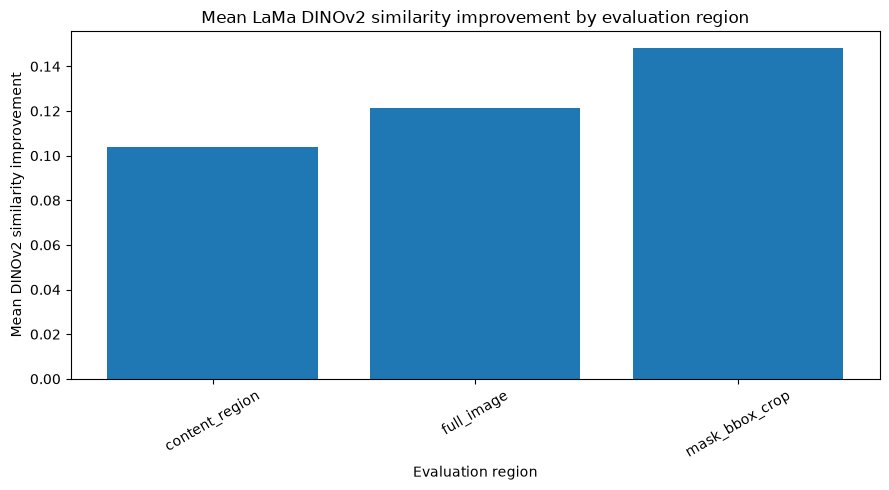

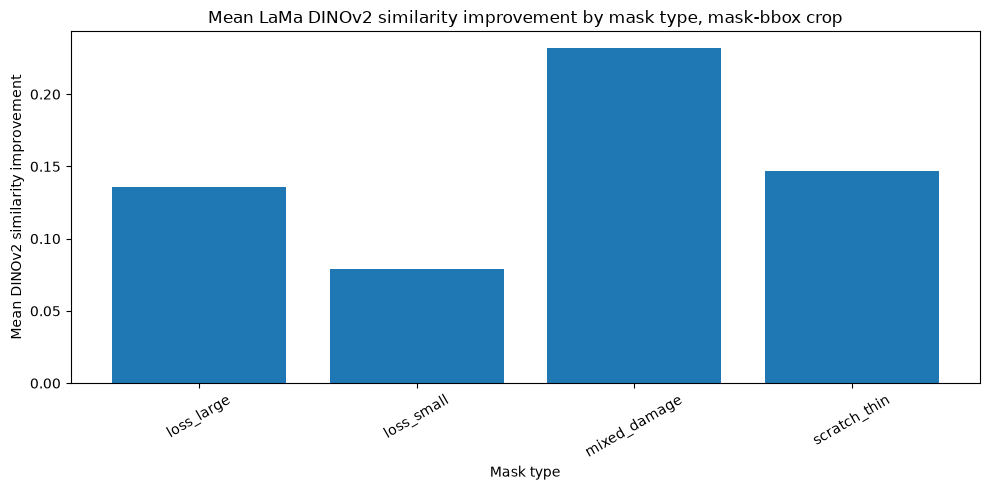

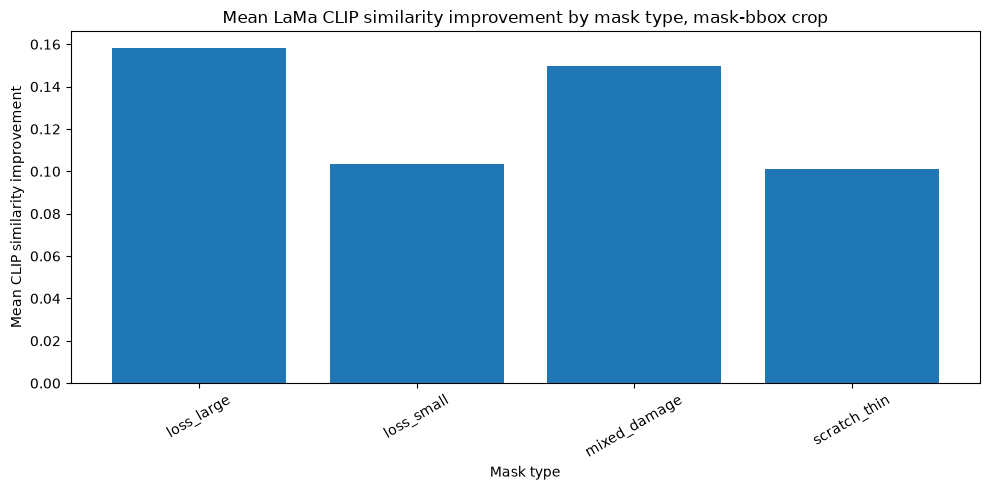

In [16]:
plot_region_df = summary_by_region_df.copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    plot_region_df["evaluation_region"],
    plot_region_df["mean_dinov2_similarity_improvement"],
)

ax.set_title("Mean LaMa DINOv2 similarity improvement by evaluation region")
ax.set_xlabel("Evaluation region")
ax.set_ylabel("Mean DINOv2 similarity improvement")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


plot_mask_df = summary_by_region_mask_type_df[
    summary_by_region_mask_type_df["evaluation_region"] == "mask_bbox_crop"
].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    plot_mask_df["mask_type"],
    plot_mask_df["mean_dinov2_similarity_improvement"],
)

ax.set_title("Mean LaMa DINOv2 similarity improvement by mask type, mask-bbox crop")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean DINOv2 similarity improvement")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    plot_mask_df["mask_type"],
    plot_mask_df["mean_clip_similarity_improvement"],
)

ax.set_title("Mean LaMa CLIP similarity improvement by mask type, mask-bbox crop")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean CLIP similarity improvement")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [17]:
expected_output_files = [
    feature_metrics_path,
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    summary_by_category_region_path,
    strongest_dinov2_cases_path,
    weakest_dinov2_cases_path,
    strongest_clip_cases_path,
    weakest_clip_cases_path,
]

for output_file in expected_output_files:
    if not output_file.exists():
        raise FileNotFoundError(f"Missing expected output file: {output_file}")

saved_feature_df = pd.read_csv(feature_metrics_path)

if len(saved_feature_df) != 700:
    raise ValueError(
        f"Expected 700 saved feature-similarity rows, found {len(saved_feature_df)}."
    )

if (saved_feature_df["status"] != "ok").any():
    display(saved_feature_df[saved_feature_df["status"] != "ok"])
    raise ValueError("Saved feature-similarity metrics contain non-ok rows.")

expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "mask_bbox_crop": 200,
}

actual_region_counts = saved_feature_df["evaluation_region"].value_counts().to_dict()

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", actual_region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = actual_region_counts.get(region, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Region {region!r}: expected {expected_count}, found {actual_count}."
        )

expected_mask_counts = {
    "loss_large": 150,
    "loss_small": 150,
    "mixed_damage": 150,
    "scratch_thin": 150,
    "zero_control": 100,
}

actual_mask_counts = saved_feature_df["mask_type"].value_counts().to_dict()

print("\nExpected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 140,
    "landscape_natural": 140,
    "architecture_structured": 140,
    "abstraction_surrealism": 140,
    "high_texture_brushwork": 140,
}

actual_category_counts = saved_feature_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

required_metric_columns = [
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
]

for metric_column in required_metric_columns:
    if saved_feature_df[metric_column].isna().any():
        raise ValueError(f"Saved feature metrics contain missing values in {metric_column!r}.")

if saved_feature_df["category"].isna().any():
    raise ValueError("Saved feature metrics contain missing category labels.")

saved_strongest_dinov2_df = pd.read_csv(strongest_dinov2_cases_path)
saved_weakest_dinov2_df = pd.read_csv(weakest_dinov2_cases_path)
saved_strongest_clip_df = pd.read_csv(strongest_clip_cases_path)
saved_weakest_clip_df = pd.read_csv(weakest_clip_cases_path)

ranking_checks = {
    "strongest_dinov2": len(saved_strongest_dinov2_df),
    "weakest_dinov2": len(saved_weakest_dinov2_df),
    "strongest_clip": len(saved_strongest_clip_df),
    "weakest_clip": len(saved_weakest_clip_df),
}

print("\nRanking row counts:", ranking_checks)

for ranking_name, row_count in ranking_checks.items():
    if row_count != 20:
        raise ValueError(
            f"Expected 20 rows for {ranking_name}, found {row_count}."
        )

print("\nSaved feature-similarity rows:", len(saved_feature_df))
print("Final LaMa feature-similarity output gates passed.")

Expected region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}

Expected mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}
Actual mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}

Expected category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
Actual category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}

Ranking row counts: {'strongest_dinov2': 20, 'weakest_dinov2': 20, 'strongest_clip': 20, 'weakest_clip': 20}

Saved feature-similarity rows: 700
Final LaMa feature-similarity output gates passed.


## Notebook 15 summary

This notebook computed CLIP and DINOv2 feature-space similarity metrics for the LaMa restoration baseline on the controlled 50-painting subset.

Feature-space similarity was computed between:

- clean reference and damaged input,
- clean reference and LaMa restored output.

The evaluated regions were:

- `full_image`,
- `content_region`,
- `mask_bbox_crop`.

Sparse masked-region feature similarity was intentionally not computed because CLIP and DINOv2 expect image-like spatial regions rather than unordered damaged pixels.

Main outputs:

- `outputs/metrics/feature_similarity_lama_50.csv`
- `outputs/metrics/feature_similarity_summary_by_mask_type_lama_50.csv`
- `outputs/metrics/feature_similarity_summary_by_category_lama_50.csv`
- `outputs/metrics/feature_similarity_summary_by_region_lama_50.csv`
- `outputs/metrics/feature_similarity_summary_by_region_mask_type_lama_50.csv`
- `outputs/metrics/feature_similarity_summary_by_category_region_lama_50.csv`
- `outputs/metrics/lama_strongest_dinov2_feature_cases_50.csv`
- `outputs/metrics/lama_weakest_dinov2_feature_cases_50.csv`
- `outputs/metrics/lama_strongest_clip_feature_cases_50.csv`
- `outputs/metrics/lama_weakest_clip_feature_cases_50.csv`

The final feature-similarity output contains 700 rows:

- 250 full-image rows,
- 250 content-region rows,
- 200 mask-bounding-box crop rows.

Feature-similarity improvement is computed as restored similarity minus damaged similarity. Positive improvement means the restored output is closer to the clean reference in the selected feature space.

These results complete the LaMa feature-space evaluation layer and prepare LaMa for later direct comparison against OpenCV Telea and future generative inpainting baselines.